# Obesity Level Prediction Using Machine Learning

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier


In [2]:
df = pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv")
df

,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
0,21.000000,Female,1.620000,64.000000,no,no,2.0,3.0,no,no,2.000000,yes,0.000000,1.000000,Sometimes,Public_Transportation,Normal_Weight
1,21.000000,Female,1.520000,56.000000,Sometimes,no,3.0,3.0,yes,yes,3.000000,yes,3.000000,0.000000,Sometimes,Public_Transportation,Normal_Weight
2,23.000000,Male,1.800000,77.000000,Frequently,no,2.0,3.0,no,no,2.000000,yes,2.000000,1.000000,Sometimes,Public_Transportation,Normal_Weight
3,27.000000,Male,1.800000,87.000000,Frequently,no,3.0,3.0,no,no,2.000000,no,2.000000,0.000000,Sometimes,Walking,Overweight_Level_I
4,22.000000,Male,1.780000,89.800000,Sometimes,no,2.0,1.0,no,no,2.000000,no,0.000000,0.000000,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,20.976842,Female,1.710730,131.408528,Sometimes,yes,3.0,3.0,no,no,1.728139,yes,1.676269,0.906247,Sometimes,Public_Transportation,Obesity_Type_III
2107,21.982942,Female,1.748584,133.742943,Sometimes,yes,3.0,3.0,no,no,2.005130,yes,1.341390,0.599270,Sometimes,Public_Transportation,Obesity_Type_III
2108,22.524036,Female,1.752206,133.689352,Sometimes,yes,3.0,3.0,no,no,2.054193,yes,1.414209,0.646288,Sometimes,Public_Transportation,Obesity_Type_III
2109,24.361936,Female,1.739450,133.346641,Sometimes,yes,3.0,3.0,no,no,2.852339,yes,1.139107,0.586035,Sometimes,Public_Transportation,Obesity_Type_III


In [3]:
df.head()

,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
0,21.0,Female,1.62,64.0,no,no,2.0,3.0,no,no,2.0,yes,0.0,1.0,Sometimes,Public_Transportation,Normal_Weight
1,21.0,Female,1.52,56.0,Sometimes,no,3.0,3.0,yes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,23.0,Male,1.80,77.0,Frequently,no,2.0,3.0,no,no,2.0,yes,2.0,1.0,Sometimes,Public_Transportation,Normal_Weight
3,27.0,Male,1.80,87.0,Frequently,no,3.0,3.0,no,no,2.0,no,2.0,0.0,Sometimes,Walking,Overweight_Level_I
4,22.0,Male,1.78,89.8,Sometimes,no,2.0,1.0,no,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [4]:
df.tail()

,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
2106,20.976842,Female,1.710730,131.408528,Sometimes,yes,3.0,3.0,no,no,1.728139,yes,1.676269,0.906247,Sometimes,Public_Transportation,Obesity_Type_III
2107,21.982942,Female,1.748584,133.742943,Sometimes,yes,3.0,3.0,no,no,2.005130,yes,1.341390,0.599270,Sometimes,Public_Transportation,Obesity_Type_III
2108,22.524036,Female,1.752206,133.689352,Sometimes,yes,3.0,3.0,no,no,2.054193,yes,1.414209,0.646288,Sometimes,Public_Transportation,Obesity_Type_III
2109,24.361936,Female,1.739450,133.346641,Sometimes,yes,3.0,3.0,no,no,2.852339,yes,1.139107,0.586035,Sometimes,Public_Transportation,Obesity_Type_III
2110,23.664709,Female,1.738836,133.472641,Sometimes,yes,3.0,3.0,no,no,2.863513,yes,1.026452,0.714137,Sometimes,Public_Transportation,Obesity_Type_III


In [5]:
df.isnull().sum()

Age                               0
Gender                            0
Height                            0
Weight                            0
CALC                              0
FAVC                              0
FCVC                              0
NCP                               0
SCC                               0
SMOKE                             0
CH2O                              0
family_history_with_overweight    0
FAF                               0
TUE                               0
CAEC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

In [6]:
df.shape

(2111, 17)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             2111 non-null   float64
 1   Gender                          2111 non-null   object 
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   CALC                            2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   SCC                             2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  family_history_with_overweight  2111 non-null   object 
 12  FAF                             21

In [8]:
df.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [9]:
df.duplicated

<bound method DataFrame.duplicated of             Age  Gender    Height      Weight        CALC FAVC  FCVC  NCP  \
0     21.000000  Female  1.620000   64.000000          no   no   2.0  3.0   
1     21.000000  Female  1.520000   56.000000   Sometimes   no   3.0  3.0   
2     23.000000    Male  1.800000   77.000000  Frequently   no   2.0  3.0   
3     27.000000    Male  1.800000   87.000000  Frequently   no   3.0  3.0   
4     22.000000    Male  1.780000   89.800000   Sometimes   no   2.0  1.0   
...         ...     ...       ...         ...         ...  ...   ...  ...   
2106  20.976842  Female  1.710730  131.408528   Sometimes  yes   3.0  3.0   
2107  21.982942  Female  1.748584  133.742943   Sometimes  yes   3.0  3.0   
2108  22.524036  Female  1.752206  133.689352   Sometimes  yes   3.0  3.0   
2109  24.361936  Female  1.739450  133.346641   Sometimes  yes   3.0  3.0   
2110  23.664709  Female  1.738836  133.472641   Sometimes  yes   3.0  3.0   

      SCC SMOKE      CH2O family_hist

In [10]:
df['BMI'] = df['Weight'] / (df['Height'] ** 2)

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize']=(8,5)

C:\Users\dyson\AppData\Local\Temp\ipykernel_22468\1894656379.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='NObeyesdad', data=df, palette='Set2')


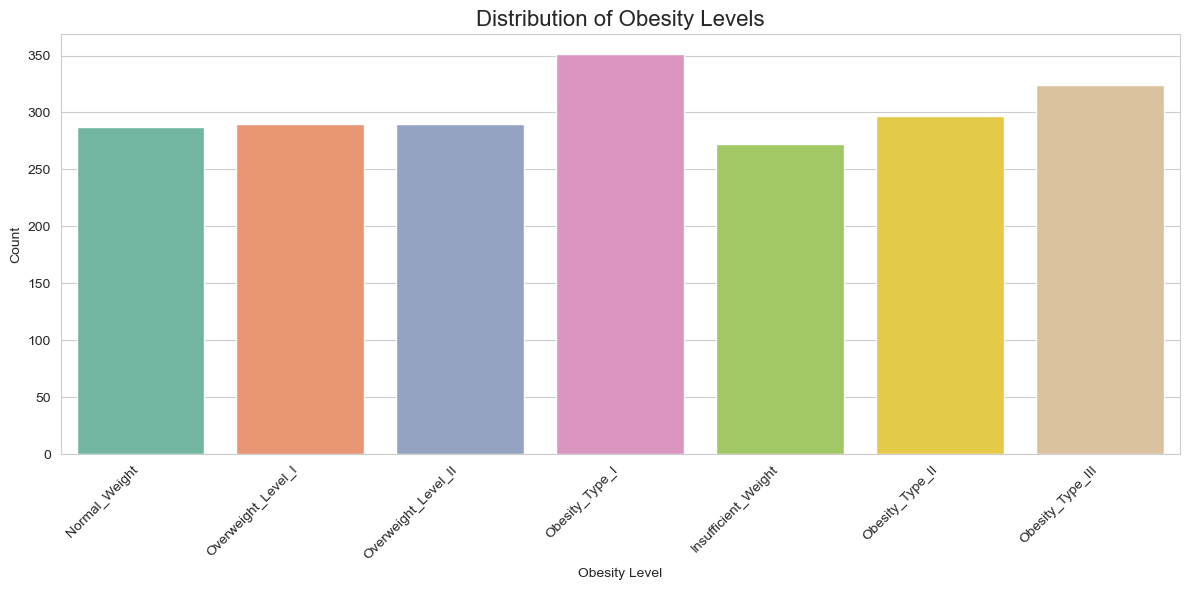

In [12]:
plt.figure(figsize=(12,6))

sns.countplot(x='NObeyesdad', data=df, palette='Set2')

plt.title("Distribution of Obesity Levels",fontsize=16)
plt.xlabel("Obesity Level")
plt.ylabel("Count")
plt.xticks(rotation=45,ha='right')

plt.tight_layout()
plt.show()

C:\Users\dyson\AppData\Local\Temp\ipykernel_22468\2259928043.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gender',data=df,palette='pastel')


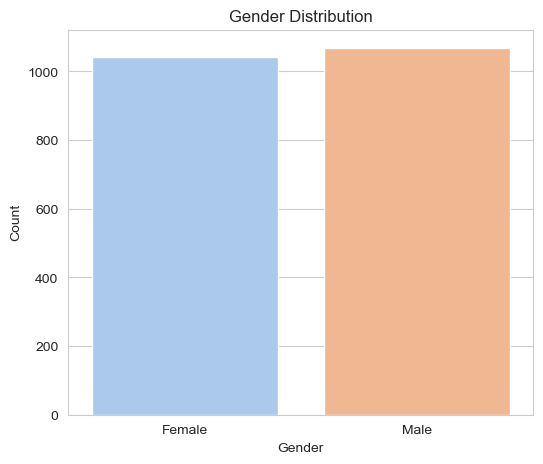

In [13]:
plt.figure(figsize=(6,5))

sns.countplot(x='Gender',data=df,palette='pastel')

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

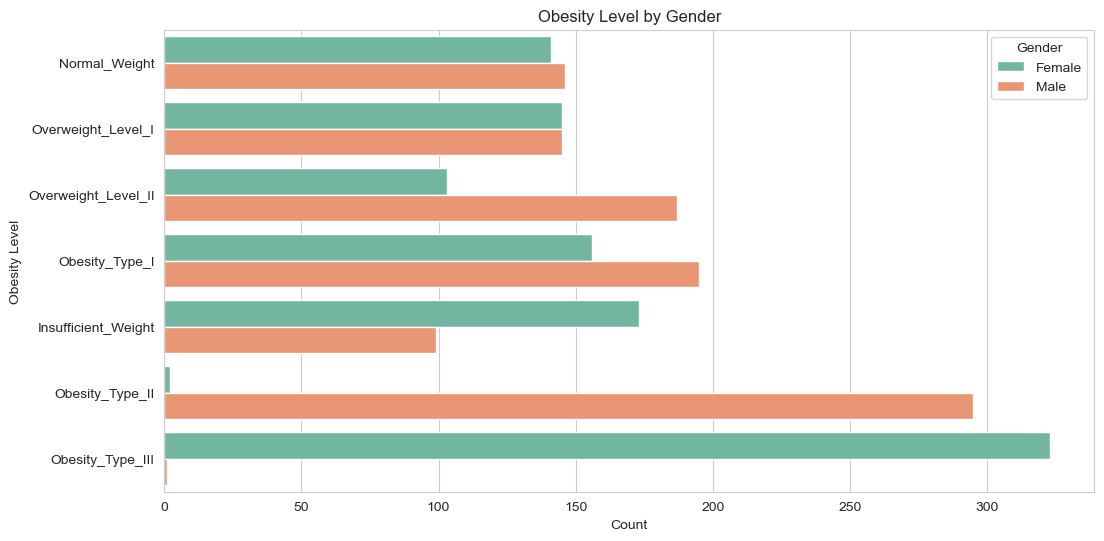

In [14]:
plt.figure(figsize=(12,6))

sns.countplot(
    y='NObeyesdad',
    hue='Gender',
    data=df,
    palette='Set2'
)

plt.title("Obesity Level by Gender")
plt.xlabel("Count")
plt.ylabel("Obesity Level")

plt.show()

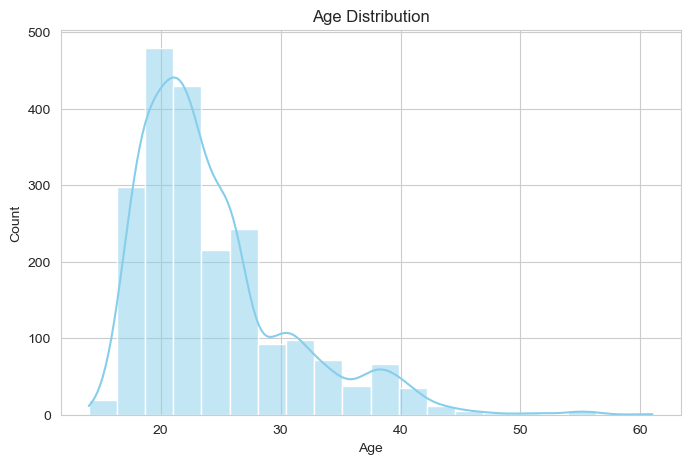

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'],bins=20,kde=True,color='skyblue')

plt.title("Age Distribution")
plt.xlabel("Age")

plt.show()

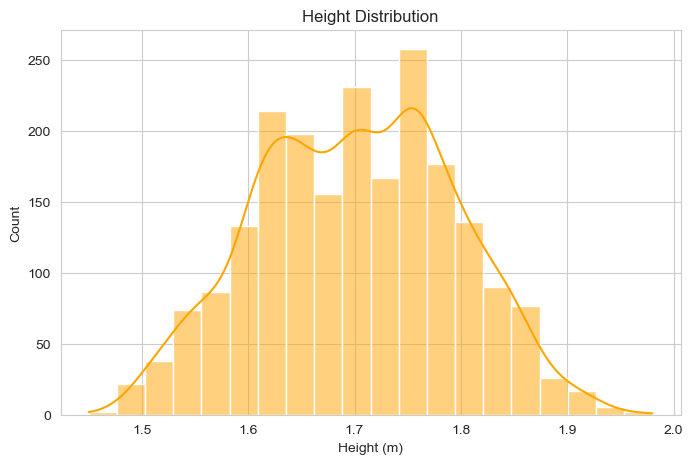

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(df['Height'],bins=20,kde=True,color='orange')

plt.title("Height Distribution")
plt.xlabel("Height (m)")

plt.show()

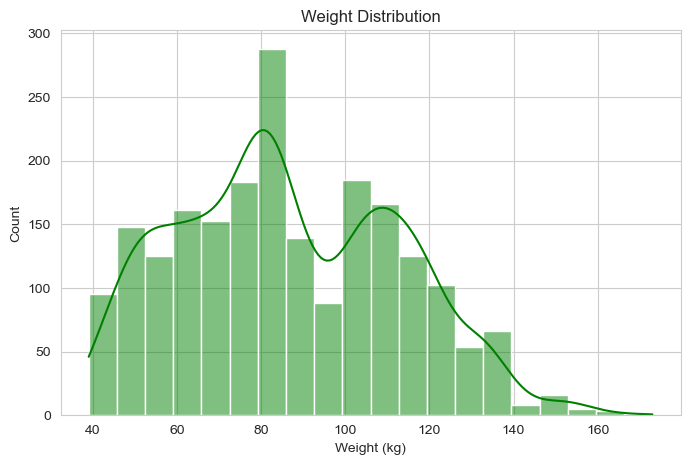

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(df['Weight'],bins=20,kde=True,color='green')

plt.title("Weight Distribution")
plt.xlabel("Weight (kg)")

plt.show()

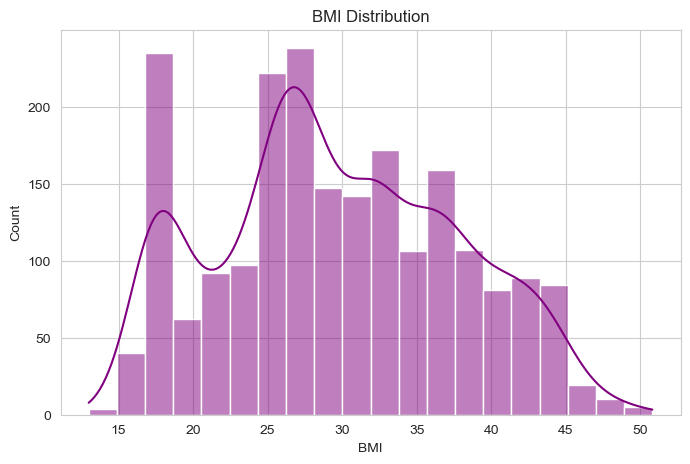

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(df['BMI'],bins=20,kde=True,color='purple')

plt.title("BMI Distribution")
plt.xlabel("BMI")

plt.show()

C:\Users\dyson\AppData\Local\Temp\ipykernel_22468\3379725343.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


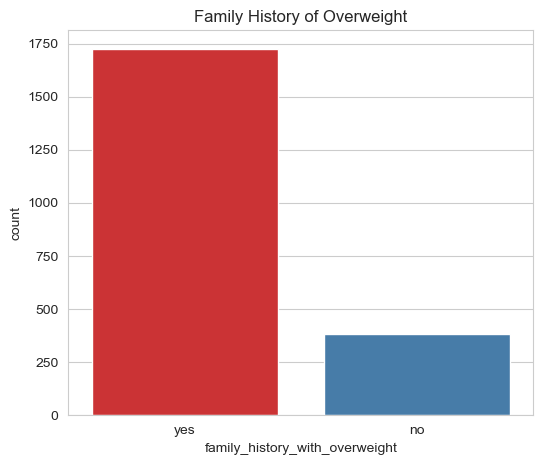

In [19]:
plt.figure(figsize=(6,5))

sns.countplot(
    x='family_history_with_overweight',
    data=df,
    palette='Set1'
)

plt.title("Family History of Overweight")

plt.show()

C:\Users\dyson\AppData\Local\Temp\ipykernel_22468\2215885214.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


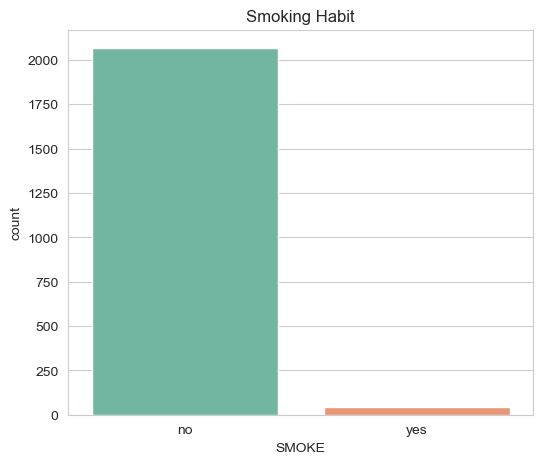

In [20]:
plt.figure(figsize=(6,5))

sns.countplot(
    x='SMOKE',
    data=df,
    palette='Set2'
)

plt.title("Smoking Habit")

plt.show()

In [21]:
df.dtypes

Age                               float64
Gender                             object
Height                            float64
Weight                            float64
CALC                               object
FAVC                               object
FCVC                              float64
NCP                               float64
SCC                                object
SMOKE                              object
CH2O                              float64
family_history_with_overweight     object
FAF                               float64
TUE                               float64
CAEC                               object
MTRANS                             object
NObeyesdad                         object
BMI                               float64
dtype: object

In [22]:
from sklearn.preprocessing import LabelEncoder

# Label encoder for input features
feature_encoder = LabelEncoder()

categorical_columns = [
    'Gender',
    'family_history_with_overweight',
    'FAVC',
    'CAEC',
    'SMOKE',
    'SCC',
    'CALC',
    'MTRANS'
]

for col in categorical_columns:
    df[col] = feature_encoder.fit_transform(df[col])

# Separate encoder for target column
target_encoder = LabelEncoder()

df['NObeyesdad'] = target_encoder.fit_transform(df['NObeyesdad'])

In [23]:
df.head()

,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad,BMI
0,21.0,0,1.62,64.0,3,0,2.0,3.0,0,0,2.0,1,0.0,1.0,2,3,1,24.386526
1,21.0,0,1.52,56.0,2,0,3.0,3.0,1,1,3.0,1,3.0,0.0,2,3,1,24.238227
2,23.0,1,1.80,77.0,1,0,2.0,3.0,0,0,2.0,1,2.0,1.0,2,3,1,23.765432
3,27.0,1,1.80,87.0,1,0,3.0,3.0,0,0,2.0,0,2.0,0.0,2,4,5,26.851852
4,22.0,1,1.78,89.8,2,0,2.0,1.0,0,0,2.0,0,0.0,0.0,2,3,6,28.342381


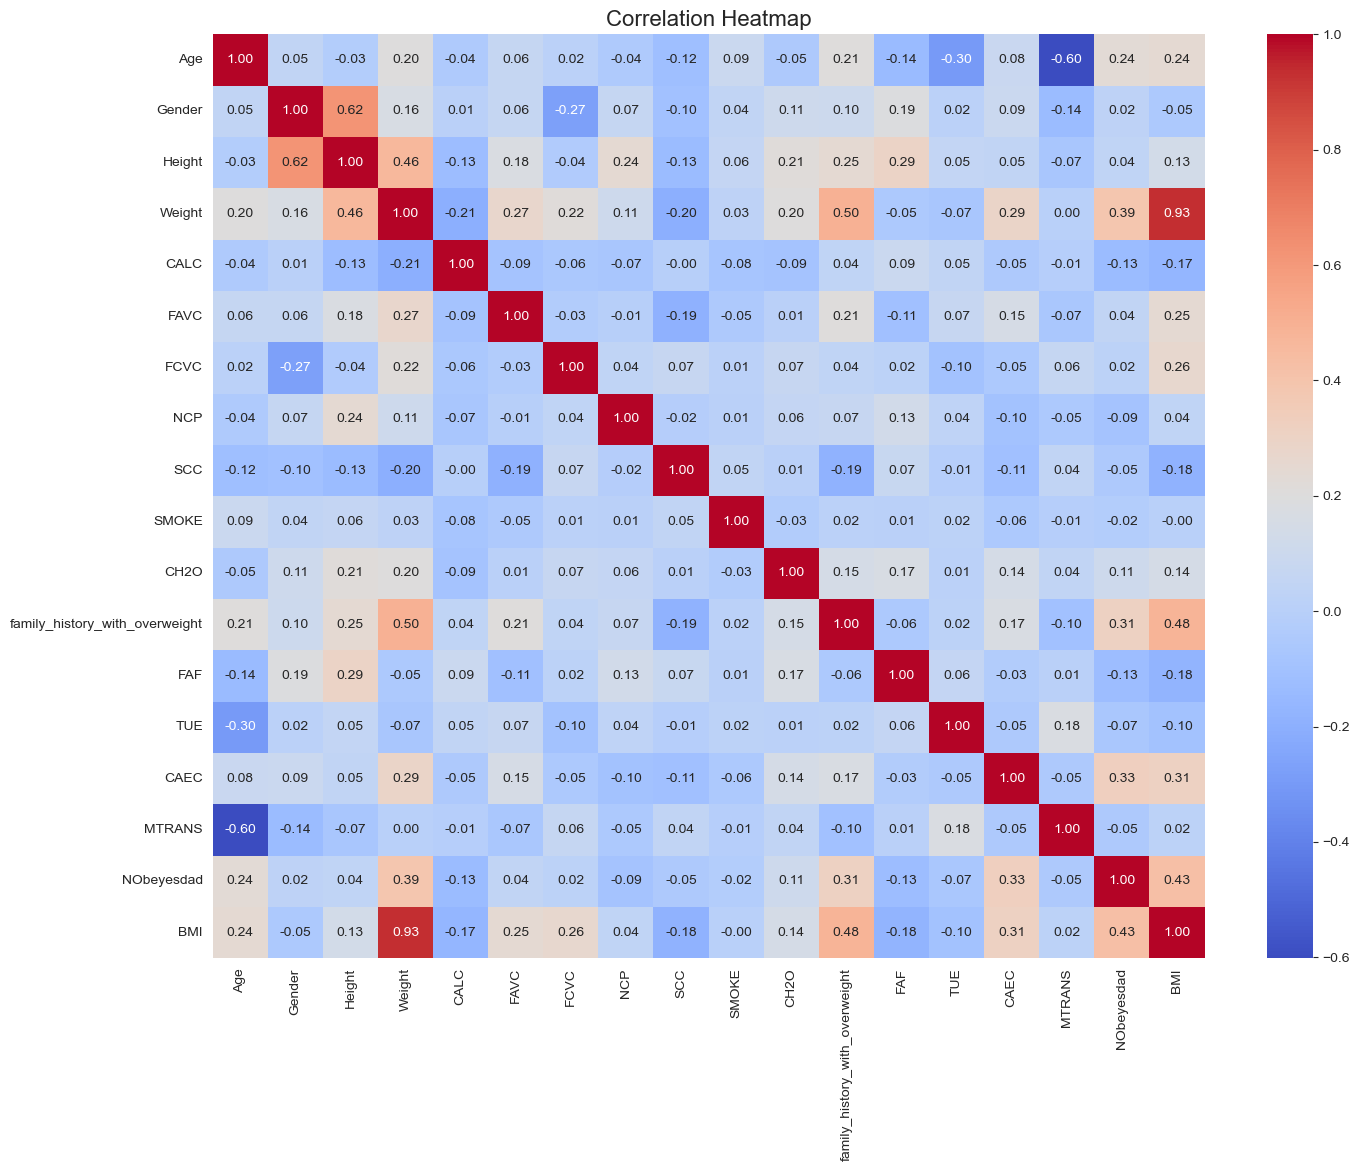

In [24]:
plt.figure(figsize=(16,12))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap",fontsize=16)

plt.show()

In [25]:
X = df.drop('NObeyesdad', axis=1)

y = df['NObeyesdad']

In [26]:
X.head()

,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,BMI
0,21.0,0,1.62,64.0,3,0,2.0,3.0,0,0,2.0,1,0.0,1.0,2,3,24.386526
1,21.0,0,1.52,56.0,2,0,3.0,3.0,1,1,3.0,1,3.0,0.0,2,3,24.238227
2,23.0,1,1.80,77.0,1,0,2.0,3.0,0,0,2.0,1,2.0,1.0,2,3,23.765432
3,27.0,1,1.80,87.0,1,0,3.0,3.0,0,0,2.0,0,2.0,0.0,2,4,26.851852
4,22.0,1,1.78,89.8,2,0,2.0,1.0,0,0,2.0,0,0.0,0.0,2,3,28.342381


In [27]:
y.head()

0    1
1    1
2    1
3    5
4    6
Name: NObeyesdad, dtype: int64

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [29]:
print("Training Features :",X_train.shape)
print("Testing Features :",X_test.shape)

print("Training Labels :",y_train.shape)
print("Testing Labels :",y_test.shape)

Training Features : (1688, 17)
Testing Features : (423, 17)
Training Labels : (1688,)
Testing Labels : (423,)


In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [31]:
print(X_train[:5])

[[-0.83092317  0.98705066  0.620541   -0.28986883 -2.46311842  0.36973009
  -0.80958529  0.40235323 -0.22010726 -0.1497019   1.60192666  0.46584884
  -0.02425737  2.2420223  -1.85604788  0.50050071 -0.52324769]
 [-0.36149465  0.98705066  0.51399505 -0.63541663  1.41356586 -2.70467575
  -0.80958529  0.40235323 -0.22010726 -0.1497019   1.60192666 -2.14661907
  -0.02425737  0.57645383  0.29870372  0.50050071 -0.85376335]
 [-0.98739934  0.98705066 -0.01873468 -1.19981136 -0.52477628  0.36973009
   1.08020206  0.40235323 -0.22010726 -0.1497019  -0.02930516  0.46584884
   2.33611435 -1.08911463  0.29870372  0.50050071 -1.31862498]
 [-0.75168536  0.98705066  1.30721898  0.04247248 -0.52477628  0.36973009
   0.69007625  1.41976449 -0.22010726 -0.1497019   0.67058953  0.46584884
   1.26750562 -0.43394995  0.29870372  0.50050071 -0.41953033]
 [-1.13053592 -1.01311923 -1.77015828 -1.12459236 -0.52477628  0.36973009
  -0.86146941 -0.44964075  4.54323955 -0.1497019  -0.50061045 -2.14661907
  -1.091

In [32]:
import pickle

pickle.dump(feature_encoder, open("feature_encoder.pkl", "wb"))
pickle.dump(target_encoder, open("target_encoder.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

In [33]:
# Logistic Regression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy :", round(lr_acc*100,2),"%")

Logistic Regression Accuracy : 91.96 %


In [34]:
# Decision Tree

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy :", round(dt_acc*100,2),"%")

Decision Tree Accuracy : 97.64 %


In [35]:
# Random Forest

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy :", round(rf_acc*100,2),"%")

Random Forest Accuracy : 99.05 %


In [36]:
# KNN

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

knn_acc = accuracy_score(y_test, knn_pred)

print("KNN Accuracy :", round(knn_acc*100,2),"%")

KNN Accuracy : 83.22 %


In [37]:
accuracy = pd.DataFrame({
    'Model':[
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'KNN'
    ],

    'Accuracy':[
        lr_acc,
        dt_acc,
        rf_acc,
        knn_acc
    ]
})

accuracy

,Model,Accuracy
0,Logistic Regression,0.919622
1,Decision Tree,0.976359
2,Random Forest,0.990544
3,KNN,0.832151


In [38]:
accuracy['Accuracy'] = accuracy['Accuracy']*100

accuracy

,Model,Accuracy
0,Logistic Regression,91.962175
1,Decision Tree,97.635934
2,Random Forest,99.054374
3,KNN,83.215130


In [39]:
accuracy = accuracy.sort_values(
    by='Accuracy',
    ascending=False
)

accuracy

,Model,Accuracy
2,Random Forest,99.054374
1,Decision Tree,97.635934
0,Logistic Regression,91.962175
3,KNN,83.215130


In [40]:
print("Best Model")

accuracy.head(1)

Best Model


,Model,Accuracy
2,Random Forest,99.054374


C:\Users\dyson\AppData\Local\Temp\ipykernel_22468\1316335959.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


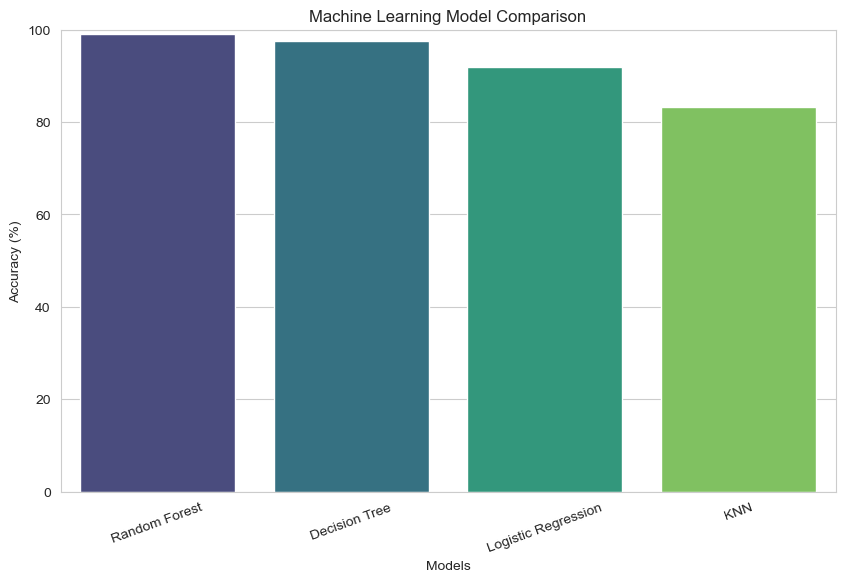

In [41]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=accuracy,
    palette='viridis'
)

plt.title("Machine Learning Model Comparison")

plt.ylabel("Accuracy (%)")

plt.xlabel("Models")

plt.ylim(0,100)

plt.xticks(rotation=20)

plt.show()

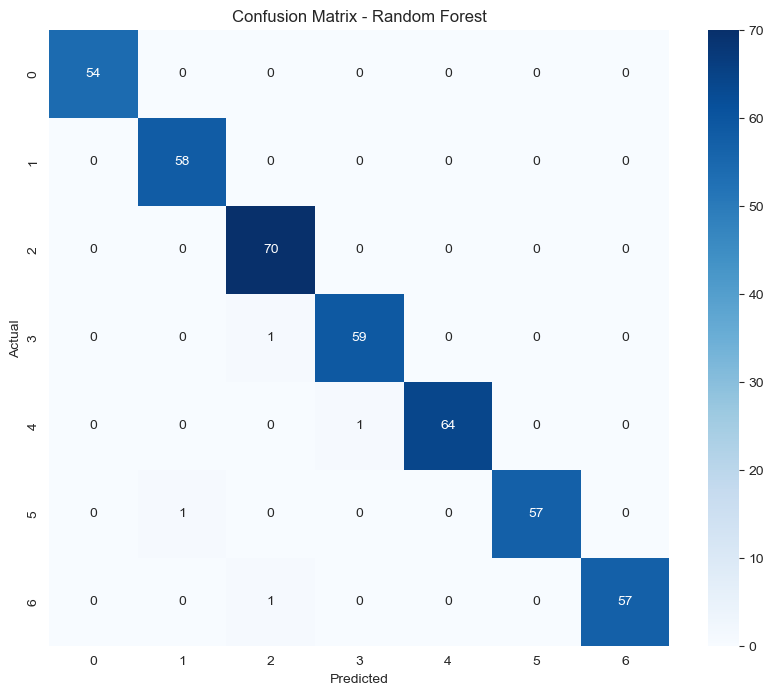

In [42]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [43]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        54
           1       0.98      1.00      0.99        58
           2       0.97      1.00      0.99        70
           3       0.98      0.98      0.98        60
           4       1.00      0.98      0.99        65
           5       1.00      0.98      0.99        58
           6       1.00      0.98      0.99        58

    accuracy                           0.99       423
   macro avg       0.99      0.99      0.99       423
weighted avg       0.99      0.99      0.99       423



In [44]:
importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
16,BMI,0.425660
3,Weight,0.199791
6,FCVC,0.059774
0,Age,0.051612
2,Height,0.048392
1,Gender,0.043744
7,NCP,0.028158
12,FAF,0.022413
13,TUE,0.021232
14,CAEC,0.021212


C:\Users\dyson\AppData\Local\Temp\ipykernel_22468\4143224472.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


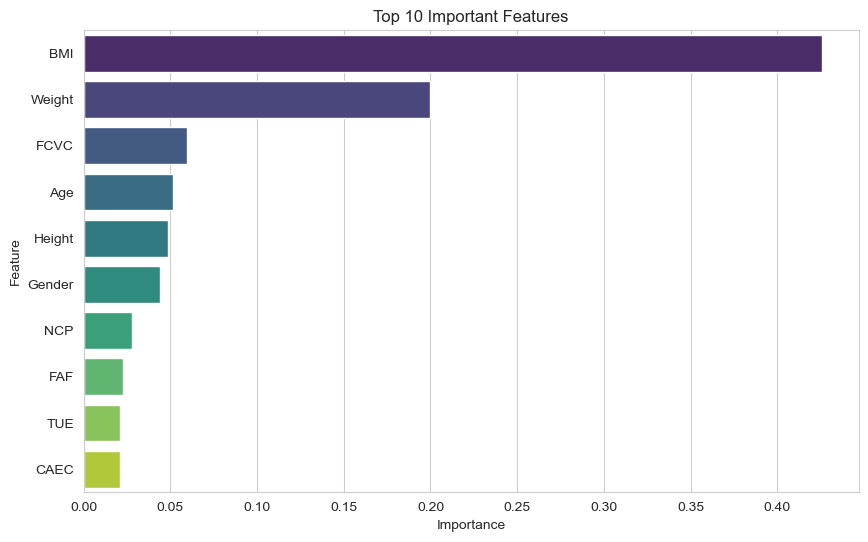

In [45]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(10),
    palette='viridis'
)

plt.title("Top 10 Important Features")

plt.show()

In [46]:
predictions = rf.predict(X_test)

predictions[:10]

array([0, 1, 6, 4, 3, 2, 3, 1, 2, 1])

In [47]:
comparison = pd.DataFrame({
    "Actual":y_test,
    "Predicted":predictions
})

comparison.head(20)

,Actual,Predicted
572,0,0
370,1,1
1002,6,6
1837,4,4
1724,3,3
1329,2,2
1736,3,3
172,1,1
1305,2,2
784,5,1


In [48]:
sample = X_test[0].reshape(1,-1)

prediction = rf.predict(sample)

print("Predicted Class :",prediction)

Predicted Class : [0]


In [49]:
target_encoder = pickle.load(open("target_encoder.pkl","rb"))

print(target_encoder.inverse_transform(prediction))
print(target_encoder.classes_)

['Insufficient_Weight']
['Insufficient_Weight' 'Normal_Weight' 'Obesity_Type_I' 'Obesity_Type_II'
 'Obesity_Type_III' 'Overweight_Level_I' 'Overweight_Level_II']


In [50]:
import pickle

pickle.dump(rf,open("obesity_model.pkl","wb"))

In [51]:
loaded_model = pickle.load(open("obesity_model.pkl","rb"))

In [52]:
prediction = loaded_model.predict(sample)

print(prediction)
print(prediction)
print(type(prediction))

[0]
[0]
<class 'numpy.ndarray'>


In [53]:
prediction = loaded_model.predict(sample)

predicted_class = target_encoder.inverse_transform(prediction)

print("=" * 40)
print("      OBESITY LEVEL PREDICTION")
print("=" * 40)
print("Predicted Class :", predicted_class[0])
print("=" * 40)

      OBESITY LEVEL PREDICTION
Predicted Class : Insufficient_Weight


In [54]:
pip install gradio

Note: you may need to restart the kernel to use updated packages.


In [55]:
import gradio as gr
import numpy as np

In [56]:
def predict_obesity(
    Gender,
    Age,
    Height,
    Weight,
    Family_History,
    FAVC,
    FCVC,
    NCP,
    CAEC,
    SMOKE,
    CH2O,
    SCC,
    FAF,
    TUE,
    CALC,
    MTRANS
):

    # Convert categorical values to numbers
    gender = {"Female": 0, "Male": 1}[Gender]

    family = {"No": 0, "Yes": 1}[Family_History]

    favc = {"No": 0, "Yes": 1}[FAVC]

    smoke = {"No": 0, "Yes": 1}[SMOKE]

    scc = {"No": 0, "Yes": 1}[SCC]

    caec = {
        "No": 0,
        "Sometimes": 1,
        "Frequently": 2,
        "Always": 3
    }[CAEC]

    calc = {
        "No": 0,
        "Sometimes": 1,
        "Frequently": 2,
        "Always": 3
    }[CALC]

    mtrans = {
        "Automobile": 0,
        "Bike": 1,
        "Motorbike": 2,
        "Public Transportation": 3,
        "Walking": 4
    }[MTRANS]

    bmi = Weight / (Height ** 2)

    data = pd.DataFrame([[
        gender,
        Age,
        Height,
        Weight,
        family,
        favc,
        FCVC,
        NCP,
        caec,
        smoke,
        CH2O,
        scc,
        FAF,
        TUE,
        calc,
        mtrans,
        bmi
    ]], columns=X.columns)

    data = scaler.transform(data)

    prediction = loaded_model.predict(data)

    prediction = target_encoder.inverse_transform(prediction)

    return prediction[0]

In [57]:
import gradio as gr

interface = gr.Interface(
    fn=predict_obesity,

    inputs=[

        gr.Dropdown(
            ["Female", "Male"],
            label="Gender"
        ),

        gr.Number(label="Age"),

        gr.Number(label="Height (meters)"),

        gr.Number(label="Weight (kg)"),

        gr.Dropdown(
            ["No", "Yes"],
            label="Family History of Overweight"
        ),

        gr.Dropdown(
            ["No", "Yes"],
            label="Frequent High-Calorie Food (FAVC)"
        ),

        gr.Slider(
            1, 3,
            step=1,
            label="Vegetable Consumption (FCVC)"
        ),

        gr.Slider(
            1, 4,
            step=1,
            label="Main Meals per Day (NCP)"
        ),

        gr.Dropdown(
            ["No", "Sometimes", "Frequently", "Always"],
            label="Food Between Meals (CAEC)"
        ),

        gr.Dropdown(
            ["No", "Yes"],
            label="Smoking"
        ),

        gr.Slider(
            1, 3,
            step=0.5,
            label="Daily Water Intake (CH2O)"
        ),

        gr.Dropdown(
            ["No", "Yes"],
            label="Calories Monitoring (SCC)"
        ),

        gr.Slider(
            0, 3,
            step=0.5,
            label="Physical Activity (FAF)"
        ),

        gr.Slider(
            0, 2,
            step=0.5,
            label="Technology Usage (TUE)"
        ),

        gr.Dropdown(
            ["No", "Sometimes", "Frequently", "Always"],
            label="Alcohol Consumption (CALC)"
        ),

        gr.Dropdown(
            [
                "Automobile",
                "Bike",
                "Motorbike",
                "Public Transportation",
                "Walking"
            ],
            label="Mode of Transportation"
        )

    ],

    outputs=gr.Textbox(label="Predicted Obesity Level"),

    title="🏥 Obesity Level Prediction System",

    description="""
Enter the patient's lifestyle and physical characteristics.
The model predicts the obesity level using a trained Random Forest Classifier.
"""
)

interface.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


C:\Users\dyson\anaconda3\Lib\site-packages\gradio\routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
